In [3]:
#import necessary libraries
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xarray as xr
import scipy

import regionmask

# import regionmask

from scipy import stats
from scipy.stats import pearsonr, linregress

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

import time
from datetime import datetime, date

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates

import shapefile
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
import os

import sys
import os.path
import subprocess
import math
import csv

from netCDF4 import Dataset

#import s3fs
import copy
import json, copy
from pandas import DataFrame
from osgeo import gdal, ogr, osr

"D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_gsfc_pdsmc_tws1_meter.nc"

"D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_jpl_pdsmc_tws1_meter.nc"

"D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_csr_pdsmc_tws1_meter.nc"

In [15]:
# Check if the file was properly saved at the given location (navigate to the folder) and open it from there again
gsfc_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_gsfc_pdsmc_tws1_meter.nc')
jpl_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_jpl_pdsmc_tws1_meter.nc')
csr_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_csr_pdsmc_tws1_meter.nc')

In [16]:
gsfc_pdsmc_tws

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB ...

## Add anomalies wrt 2004-20010 to neutralize the lwe_thickness and get the anomlaies wrt to 2004-2009 used by JPL Mascons and CSR Mascons and Improved Point Mass Modelling

In [17]:
## Recently Added

baseline = slice("2004", "2010")
base_mean = gsfc_pdsmc_tws.sel(time=baseline).mean("time")
anomalies_added_gsfc_pdsmc_tws = gsfc_pdsmc_tws + base_mean    #addition here, be careful
anomalies_added_gsfc_pdsmc_tws

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.09321 -0.09309 ... -0.01671

In [18]:
base_mean

<xarray.Dataset> Size: 2MB
Dimensions:        (lon: 720, lat: 360)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
Data variables:
    lwe_thickness  (lat, lon) float64 2MB 0.009989 0.00998 ... 0.002409 0.002409

## Get anomalies wrt 2004-2009

In [19]:
# ## Recently Added

# baseline1 = slice("2004", "2009")
# base_mean1 = anomalies_added_no_filtering_csr_sh .sel(time=baseline1).mean("time") #anomalies_added_gsfc_pdsmc_tws
# anomalies2004_2009_wrt_no_filtering_csr_sh = anomalies_added_no_filtering_csr_sh - base_mean1 #anomalies_added_gsfc_pdsmc_tws
# anomalies2004_2009_wrt_no_filtering_csr_sh

In [20]:
## Recently Added

baseline1 = slice("2004", "2009")
base_mean1 = anomalies_added_gsfc_pdsmc_tws.sel(time=baseline1).mean("time")
anomalies2004_2009_wrt_gsfc_pdsmc_tws = anomalies_added_gsfc_pdsmc_tws - base_mean1
anomalies2004_2009_wrt_gsfc_pdsmc_tws

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.1032 -0.1031 ... -0.01912

In [21]:
anomalies2004_2009_wrt_gsfc_pdsmc_tws

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.1032 -0.1031 ... -0.01912

In [27]:
anomalies2004_2009_wrt_gsfc_pdsmc_tws.to_netcdf(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\anomalies2004_2009_wrt_gsfc_pdsmc_tws.nc')

------

In [24]:
gsfc = anomalies2004_2009_wrt_gsfc_pdsmc_tws['lwe_thickness'].values
jpl = jpl_pdsmc_tws['lwe_thickness'].values
csr = csr_pdsmc_tws['lwe_thickness'].values

In [25]:
def vce_weighted_average_monthly(solutions_monthly, max_iter=50):
    n_solutions = solutions_monthly.shape[0]
    weights = np.ones(n_solutions) / n_solutions # Start with equal weights, i,e. 1/3, 1/3, 1/3 for GSFC, JPL & CSR
    for _ in range(max_iter):
        # Weighted average using current weights
        combined = np.average(solutions_monthly, axis=0, weights=weights)

        # Calculate residuals for each solution
        residuals = solutions_monthly - combined

        # Calculate RMS of residuals for each solution
        rms = np.sqrt(np.mean(residuals**2, axis=(1,2)))
        rms[rms == 0] = 1e-12 # to prevent division by zero

        
        # --- weight update as in Eq. (2) as in the paper: https://doi.org/10.1007/1345_2022_163 -------
        sum_weights = np.sum(weights)
        normalized_prev_weights = weights / sum_weights
        one_minus_normalized = 1.0 - normalized_prev_weights
        new_weights = one_minus_normalized * (1.0 / (rms ** 2))
        new_weights /= new_weights.sum()  # Normalize the weight so that the weight of 3 data providers sum to 1

       # Check convergence of new weight to fifth decimal place 
        if np.all(np.round(weights, 5) == np.round(new_weights, 5)):
            break
            
        weights = new_weights
        
    return combined, weights

# Stack all solutions: shape (3, 168, 360, 720)
all_solutions = np.stack([gsfc, jpl, csr], axis=0)  # shape (3, 168, 360, 720)
n_months = all_solutions.shape[1]
weights_all = np.zeros((n_months, 3), dtype=np.float32)

for t in range(n_months):
    monthly_solutions = all_solutions[:, t, :, :]
    _, weights = vce_weighted_average_monthly(monthly_solutions)
    weights_all[t] = weights

# Compute overall weights for the entire period: April 2002 - march 2016 : 14 yr period
overall_weights = np.mean(weights_all, axis=0)
print("Overall weights for GSFC, JPL, CSR (to 5 decimals):")
print(np.round(overall_weights, 5))

Overall weights for GSFC, JPL, CSR (to 5 decimals):
[0.45038 0.22347 0.32615]


In [26]:
weights_gsfc = 0.45038
weights_jpl = 0.22347
weights_csr = 0.32615

In [28]:
# Check if the file was properly saved at the given location (navigate to the folder) and open it from there again
# gsfc_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_gsfc_pdsmc_tws1_meter.nc')

gsfc_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\anomalies2004_2009_wrt_gsfc_pdsmc_tws.nc') #anomalies2004_2009_wrt_gsfc_pdsmc_tws.nc
jpl_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_jpl_pdsmc_tws1_meter.nc')
csr_pdsmc_tws = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\Mascon_csr_pdsmc_tws1_meter.nc')

In [33]:
gsfc_pdsmc_tws

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB ...

In [34]:
weights_gsfc = 0.45038
weights_jpl = 0.22347
weights_csr = 0.32615

numerator = (
    jpl_pdsmc_tws['lwe_thickness'] * weights_jpl +
    gsfc_pdsmc_tws['lwe_thickness'] * weights_gsfc +
    csr_pdsmc_tws['lwe_thickness'] * weights_csr
)
denominator = weights_jpl + weights_gsfc + weights_csr
EWA_mascon = numerator / denominator

In [35]:
EWA_mascon

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.06491064, -0.06485434, -0.06479799, ..., -0.06507932,
         -0.06502313, -0.06496691],
        [-0.06541341, -0.06529208, -0.06517231, ..., -0.06578618,
         -0.06566051, -0.06553623],
        [-0.0540679 , -0.05390322, -0.05374313, ..., -0.05458875,
         -0.05441074, -0.05423709],
        ...,
        [-0.01536741, -0.01536741, -0.01536741, ..., -0.01751804,
         -0.01751804, -0.01751804],
        [-0.01536741, -0.01536741, -0.01536741, ..., -0.01751804,
         -0.01751804, -0.01751804],
        [-0.01745213, -0.01745213, -0.01745213, ..., -0.01745213,
         -0.01745213, -0.01745213]],

       [[-0.06165628, -0.06160057, -0.06154485, ..., -0.06182336,
         -0.06176768, -0.06171198],
        [-0.06124761, -0.06112703, -0.06100905, ..., -0.06162439,
         -0.06149634, -0.06137073],
        [-0.04917329, -0.04899837, -0.04882966, ..., -0.04973453,
         -0.04954146, -0.04935435],
...
        [-0.02145995, -0.02145995, -0.02145995, ..., -0.01744064,
         -0.01744064, -0.01744064],
        [-0.02145995, -0.02145995, -0.02145995, ..., -0.01744064,
         -0.01744064, -0.01744064],
        [-0.01329658, -0.01329658, -0.01329658, ..., -0.01329658,
         -0.01329658, -0.01329658]],

       [[ 0.1117972 ,  0.111706  ,  0.11161412, ...,  0.11206736,
          0.11197787,  0.11188783],
        [ 0.11716571,  0.11698784,  0.11681141, ...,  0.1177075 ,
          0.11752559,  0.11734498],
        [ 0.09855698,  0.09834508,  0.09814173, ...,  0.09924395,
          0.09900646,  0.09877745],
        ...,
        [-0.02604074, -0.02604074, -0.02604074, ..., -0.02342865,
         -0.02342865, -0.02342865],
        [-0.02604074, -0.02604074, -0.02604074, ..., -0.02342865,
         -0.02342865, -0.02342865],
        [-0.01584726, -0.01584726, -0.01584726, ..., -0.01584726,
         -0.01584726, -0.01584726]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31

In [36]:
EWA_mascon.attrs['grid_mapping'] = 'WGS84'
EWA_mascon.attrs['standard_name'] = 'Liquid_Water_Equivalent_Thickness'
EWA_mascon.attrs['long_name'] = 'Liquid_Water_Equivalent_Thickness'
EWA_mascon.attrs['units'] = 'meters'

# # Now export to NetCDF
# EWA_mascon.to_netcdf('EWA_mascon.nc')

In [37]:
EWA_mascon

<xarray.DataArray 'lwe_thickness' (time: 168, lat: 360, lon: 720)> Size: 348MB
array([[[-0.06491064, -0.06485434, -0.06479799, ..., -0.06507932,
         -0.06502313, -0.06496691],
        [-0.06541341, -0.06529208, -0.06517231, ..., -0.06578618,
         -0.06566051, -0.06553623],
        [-0.0540679 , -0.05390322, -0.05374313, ..., -0.05458875,
         -0.05441074, -0.05423709],
        ...,
        [-0.01536741, -0.01536741, -0.01536741, ..., -0.01751804,
         -0.01751804, -0.01751804],
        [-0.01536741, -0.01536741, -0.01536741, ..., -0.01751804,
         -0.01751804, -0.01751804],
        [-0.01745213, -0.01745213, -0.01745213, ..., -0.01745213,
         -0.01745213, -0.01745213]],

       [[-0.06165628, -0.06160057, -0.06154485, ..., -0.06182336,
         -0.06176768, -0.06171198],
        [-0.06124761, -0.06112703, -0.06100905, ..., -0.06162439,
         -0.06149634, -0.06137073],
        [-0.04917329, -0.04899837, -0.04882966, ..., -0.04973453,
         -0.04954146, -0.04935435],
...
        [-0.02145995, -0.02145995, -0.02145995, ..., -0.01744064,
         -0.01744064, -0.01744064],
        [-0.02145995, -0.02145995, -0.02145995, ..., -0.01744064,
         -0.01744064, -0.01744064],
        [-0.01329658, -0.01329658, -0.01329658, ..., -0.01329658,
         -0.01329658, -0.01329658]],

       [[ 0.1117972 ,  0.111706  ,  0.11161412, ...,  0.11206736,
          0.11197787,  0.11188783],
        [ 0.11716571,  0.11698784,  0.11681141, ...,  0.1177075 ,
          0.11752559,  0.11734498],
        [ 0.09855698,  0.09834508,  0.09814173, ...,  0.09924395,
          0.09900646,  0.09877745],
        ...,
        [-0.02604074, -0.02604074, -0.02604074, ..., -0.02342865,
         -0.02342865, -0.02342865],
        [-0.02604074, -0.02604074, -0.02604074, ..., -0.02342865,
         -0.02342865, -0.02342865],
        [-0.01584726, -0.01584726, -0.01584726, ..., -0.01584726,
         -0.01584726, -0.01584726]]], shape=(168, 360, 720))
Coordinates:
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.0 88.5 89.0 89.5
  * time     (time) datetime64[ns] 1kB 2002-04-30 2002-05-31 ... 2016-03-31
Attributes:
    grid_mapping:   WGS84
    standard_name:  Liquid_Water_Equivalent_Thickness
    long_name:      Liquid_Water_Equivalent_Thickness
    units:          meters

In [38]:
# EWA_mascon.to_netcdf(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')

EWA_mascon.to_netcdf(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')

In [6]:
# weighted_mean_mascon = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')

weighted_mean_mascon = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')
weighted_mean_mascon

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB ...

In [7]:
new_baseline = slice("2004", "2009")
new_baseline_mean = weighted_mean_mascon.sel(time=new_baseline).mean("time")
anomalies_added_weighted_mean_mascon = weighted_mean_mascon + new_baseline_mean    #addition here, be careful
anomalies_added_weighted_mean_mascon

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.06491 -0.06485 ... -0.01585

In [8]:
new_baseline2 = slice("2003-01", "2010-12")
new_baseline2_mean = anomalies_added_weighted_mean_mascon.sel(time=new_baseline2).mean("time")
anomalies2003_2010_wrt_weighted_mean_mascon = anomalies_added_weighted_mean_mascon - new_baseline2_mean
anomalies2003_2010_wrt_weighted_mean_mascon

<xarray.Dataset> Size: 348MB
Dimensions:        (lon: 720, lat: 360, time: 168)
Coordinates:
  * lon            (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * time           (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
Data variables:
    lwe_thickness  (time, lat, lon) float64 348MB -0.06656 -0.0665 ... -0.02109

In [9]:
anomalies2003_2010_wrt_weighted_mean_mascon.lwe_thickness.values

array([[[-0.06656035, -0.06650484, -0.06644925, ..., -0.06672646,
         -0.06667115, -0.06661579],
        [-0.06739179, -0.06727498, -0.06715963, ..., -0.06775067,
         -0.06762969, -0.06751005],
        [-0.05633117, -0.05617472, -0.05602288, ..., -0.05682771,
         -0.05665774, -0.0564922 ],
        ...,
        [-0.02105407, -0.02105407, -0.02105407, ..., -0.02325835,
         -0.02325835, -0.02325835],
        [-0.02105407, -0.02105407, -0.02105407, ..., -0.02325835,
         -0.02325835, -0.02325835],
        [-0.02268999, -0.02268999, -0.02268999, ..., -0.02268999,
         -0.02268999, -0.02268999]],

       [[-0.06330598, -0.06325107, -0.06319611, ..., -0.0634705 ,
         -0.0634157 , -0.06336086],
        [-0.063226  , -0.06310993, -0.06299638, ..., -0.06358888,
         -0.06346553, -0.06334455],
        [-0.05143657, -0.05126987, -0.05110941, ..., -0.05197349,
         -0.05178846, -0.05160946],
        ...,
        [-0.03670712, -0.03670712, -0.03670712, ..., -

In [10]:
anomalies2003_2010_wrt_weighted_mean_mascon.to_netcdf(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2_new_baseline.nc')

---------

In [11]:
# 1. Load and prepare the shapefile
gdf = gpd.read_file(r'D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_TotalHMA_boundary1_22.shp')
gdf_4326 = gdf.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf_4326 = gdf_4326.drop(['Primary__1'], axis=1)
dropped_gdf_4326

,Primary_ID,Area,Shape_Area,Region_No,Glacier_Ar,geometry
0,Eastern Hindu Kush,111147.061871,1.111471e+11,8,2.934299e+09,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,211514.200081,2.115142e+11,10,7.986811e+09,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,166943.561268,1.669436e+11,12,2.845696e+09,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,270268.094462,2.702681e+11,11,8.680236e+09,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,92830.485352,9.283049e+10,9,2.147510e+10,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,124880.500694,1.248805e+11,6,8.418284e+09,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,83444.425531,8.344443e+10,5,1.846039e+09,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,205724.916795,2.057249e+11,4,2.261377e+09,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,39543.166059,3.954317e+10,1,5.208770e+08,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,132813.049169,1.328130e+11,13,8.456778e+09,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [12]:
gdf1 = gpd.read_file(r"D:\MSRSGI\Masters_thesis\Data\HMA_Region_Shapefiles\Regions_shapefiles\New folder\Updated_SingleHMAboundarythatincludes1to22.shp")
gdf1_4326 = gdf1.to_crs('EPSG:4326')  # Reproject to match dataset CRS

dropped_gdf1_4326 = gdf1_4326.drop(['Primary__1'], axis=1)  #already done , so comes weror wehn done
dropped_gdf1_4326

,Primary_ID,Area,Shape_Area,Region_No,Glacier_Ar,geometry
0,High Mountain Asia Region,3.993978e+06,3.993978e+12,23,9.760176e+10,"POLYGON ((92.26394 39.3763, 92.24847 39.32136,..."


In [13]:
gdf_concat = pd.concat([dropped_gdf_4326, dropped_gdf1_4326 ], axis=0, ignore_index=True)
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,Glacier_Ar,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,2.934299e+09,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,7.986811e+09,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,2.845696e+09,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,8.680236e+09,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,2.147510e+10,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,8.418284e+09,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,1.846039e+09,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,2.261377e+09,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,5.208770e+08,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,8.456778e+09,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [14]:
# weighted_mean_mascon = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc')
# weighted_mean_mascon

In [16]:
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray
from shapely.geometry import mapping

# # 1. Load and prepare the shapefile
# gdf = gpd.read_file(r'D:/MSRSGI/Masters_thesis/Data/HMA_Region_Shapefiles/Regions_shapefiles/HMA_region_annoted_final.shp')
# gdf_4326 = gdf.to_crs('EPSG:4326')  # Reproject to match dataset CRS


# 2. Load the lwe_thickness dataset 
# ds = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Processed Data\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2.nc') #old file

ds = xr.open_dataset(r'D:\MSRSGI\Lab Rotation\Physical Geodesy\Python_Workspace\Organaized\Mascon\Combined\Result\Output_Data\Mascon_approach\VCE_EWA_mascon_pdsmc_tws1_meter_attribute2_new_baseline.nc')
da = ds['lwe_thickness']  # Get the DataArray

# 3. Define the provided functions
def area_weighting(grid_resolution):
    """
    Calculate the area of each grid, globally, corresponding to the latitudes and longitudes.
    """
    longitude_grid = np.linspace(0, 359+(1-grid_resolution), int(360/grid_resolution), dtype='float')
    latitude_grid = np.linspace(0, 179+(1-grid_resolution), int(180/grid_resolution), dtype='float')
    longitude_grid1 = np.linspace(1*grid_resolution, 360, int(360/grid_resolution), dtype='float')
    latitude_grid1 = np.linspace(1*grid_resolution, 180, int(180/grid_resolution), dtype='float')
    
    lambd,theta = np.meshgrid(longitude_grid, latitude_grid)  
    lambd1,theta1 = np.meshgrid(longitude_grid1, latitude_grid1)
    
    delta_latitude = np.sin(np.deg2rad(90-theta)) - np.sin(np.deg2rad(90-theta1))
    delta_longitude = (lambd1 - lambd) * np.pi/180

    # Area of each grid in m²
    area = (6378.137**2) * pow(10,6) * (np.multiply(delta_latitude, delta_longitude))
    return area

def Basinaverage(temp, gs, shp_basin, basin_area):
    """
    Calculate the basin average of the total water storage (TWS).
    """
    # Apply area weighting to the data
    temp_weighted = temp.copy()
    temp_weighted = temp * area_weighting(gs)  # Convert to volume
    
    # Set spatial dimensions and CRS
    basin_tws = temp_weighted.rio.write_crs("EPSG:4326", inplace=True)
    basin_tws = basin_tws.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            
    # Clip data to basin shape
    basin_tws = basin_tws.rio.clip(shp_basin.geometry.apply(mapping), shp_basin.crs, drop=True)
    
    # Calculate basin average TWS
    basin_avg_tws = basin_tws.sum(dim=('lon','lat'), skipna=True) / basin_area
    
    # Clean up spatial references
    if 'spatial_ref' in basin_avg_tws.coords:
        basin_avg_tws = basin_avg_tws.drop_vars('spatial_ref')
    
    return basin_avg_tws

# 4. Process each region
results = []
grid_resolution = 0.5  # Grid resolution in degrees

#for idx, region in gdf_4326.iterrows():
for idx, region in gdf_concat.iterrows():
    region_name = region.Primary_ID
    region_area = region.Shape_Area  # Exact region area from shapefile
    number_region = region.Region_No #latest
    
    #  GeoDataFrame
    region_gdf = gpd.GeoDataFrame({
        'geometry': [region.geometry],
        'Primary_ID': [region_name],
        'Region_No': [number_region],
        'Shape_Area': [region_area]
    }, crs=gdf_concat.crs)   #gdf_4326 is replaced by gdf_concat
    
    # Calculate the basin average using the reference function
    basin_avg = Basinaverage(da, grid_resolution, region_gdf, region_area)
    
    # # Add region metadata
    # basin_avg = basin_avg.assign_attrs({
    #     'region_name': region_name,
    #     #'region_area_m2': float(region_area),
    #     'region_area_m2': region_area,
    #     'region_id': number_region
    # })

    meta = xr.Dataset({
    'region_id': result_ds.region_id,
    'region_area_m2': result_ds.region_area_m2}, coords={'region': result_ds.region})

    # print(meta.to_dataframe())
    
    basin_avg = basin_avg.expand_dims(region=[region_name])
    basin_avg = basin_avg.assign_coords({
    'region_area_m2': ('region', [region_area]),
    'region_id': ('region', [number_region])})
    results.append(basin_avg)

# 5. Combine all regions into a single dataset
result_ds = xr.concat(results, dim='region')

In [17]:
result_ds

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[ 0.08280867,  0.10361452,  0.05165508, ..., -0.09495755,
        -0.10250277,  0.04047855],
       [ 0.09162188,  0.0856283 ,  0.06471236, ..., -0.04314442,
        -0.04107675, -0.02903267],
       [ 0.01615076,  0.03796271,  0.09794943, ..., -0.23534299,
        -0.26545711, -0.33938097],
       ...,
       [ 0.04879599,  0.07417363,  0.06990785, ..., -0.17064356,
        -0.1380114 , -0.14346661],
       [ 0.00190813,  0.01249719,  0.00173147, ..., -0.01928384,
        -0.03111881, -0.03703995],
       [ 0.010616  ,  0.01241774,  0.01829081, ..., -0.08113476,
        -0.07926023, -0.08127192]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23

In [18]:
result_ds_mm = result_ds * 1000
result_ds_mm

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[  82.80867183,  103.61452041,   51.65508047, ...,  -94.95754594,
        -102.50277096,   40.4785475 ],
       [  91.62187962,   85.62830159,   64.71236155, ...,  -43.1444157 ,
         -41.07675369,  -29.03266606],
       [  16.1507642 ,   37.96270712,   97.94942622, ..., -235.34299064,
        -265.45710703, -339.38096765],
       ...,
       [  48.79599136,   74.17363175,   69.90785382, ..., -170.64355987,
        -138.01140198, -143.46660578],
       [   1.90813178,   12.49719408,    1.73146781, ...,  -19.28384414,
         -31.11881343,  -37.0399518 ],
       [  10.61600344,   12.41774155,   18.290813  , ...,  -81.13476129,
         -79.26022798,  -81.27191811]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23

In [19]:
result_ds_mm.attrs['units'] = 'mm'

In [20]:
result_ds_mm

<xarray.DataArray 'lwe_thickness' (region: 23, time: 168)> Size: 31kB
array([[  82.80867183,  103.61452041,   51.65508047, ...,  -94.95754594,
        -102.50277096,   40.4785475 ],
       [  91.62187962,   85.62830159,   64.71236155, ...,  -43.1444157 ,
         -41.07675369,  -29.03266606],
       [  16.1507642 ,   37.96270712,   97.94942622, ..., -235.34299064,
        -265.45710703, -339.38096765],
       ...,
       [  48.79599136,   74.17363175,   69.90785382, ..., -170.64355987,
        -138.01140198, -143.46660578],
       [   1.90813178,   12.49719408,    1.73146781, ...,  -19.28384414,
         -31.11881343,  -37.0399518 ],
       [  10.61600344,   12.41774155,   18.290813  , ...,  -81.13476129,
         -79.26022798,  -81.27191811]], shape=(23, 168))
Coordinates:
  * region          (region) object 184B 'Eastern Hindu Kush' ... 'High Mount...
  * time            (time) datetime64[ns] 1kB 2002-04-30 ... 2016-03-31
    region_area_m2  (region) float64 184B 1.111e+11 2.115e+11 ... 3.994e+12
    region_id       (region) int64 184B 8 10 12 11 9 6 5 4 ... 22 14 15 2 3 7 23
Attributes:
    units:    mm

In [21]:
meta.to_dataframe()

,region_area_m2,region_id
region,,
Eastern Hindu Kush,1.111471e+11,8
Western Himalaya,2.115142e+11,10
Eastern Himalaya,1.669436e+11,12
Central Himalaya,2.702681e+11,11
Karakoram,9.283049e+10,9
Western Pamir,1.248805e+11,6
Pamir Alay,8.344443e+10,5
Northern/Western Tien Shan,2.057249e+11,4
Dzhungarsky Alatau,3.954317e+10,1


In [22]:
# 6. Save to NetCDF
# result_ds_mm.to_netcdf(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_HMA_regional_averages_WeightedMeanMascon_mm_End.nc')

result_ds_mm.to_netcdf(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_HMA_regional_averages_WeightedMeanMascon_mm_End1.nc')

In [23]:
# Load the dataset
# ds = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_HMA_regional_averages_WeightedMeanMascon_mm_End.nc')

ds = xr.open_dataset(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_HMA_regional_averages_WeightedMeanMascon_mm_End1.nc')

# Rearrange dimensions to (time, region)
da = ds['lwe_thickness'].transpose('time', 'region')

# Convert to pandas DataFrame
df = da.to_pandas()  # time as index, region names as columns
df

region,Eastern Hindu Kush,Western Himalaya,Eastern Himalaya,Central Himalaya,Karakoram,Western Pamir,Pamir Alay,Northern/Western Tien Shan,Dzhungarsky Alatau,Western Kunlun Shan,...,Tibetan Interior Mountains,Tanggula Shan,Eastern Tibetan Mountains,Qilian Shan,Eastern Kunlun Shan,Altun Shan,Eastern Tien Shan,Central Tien Shan,Eastern Pamir,High Mountain Asia Region
time,,,,,,,,,,,,,,,,,,,,,
2002-04-30,82.808672,91.621880,16.150764,53.512461,21.518603,78.356825,68.707973,37.174759,49.599194,-35.841615,...,-30.755265,-27.437077,-39.973843,-9.109581,-51.741306,-8.871389,69.802196,48.795991,1.908132,10.616003
2002-05-31,103.614520,85.628302,37.962707,32.606351,27.540316,107.075237,88.784673,48.367361,57.364504,-31.863278,...,-38.083226,-29.432425,-44.614896,-17.109821,-54.519310,-13.429957,84.662027,74.173632,12.497194,12.417742
2002-06-30,51.655080,64.712362,97.949426,70.728108,6.088602,58.020015,50.395808,34.036352,44.683729,-32.126090,...,-28.104765,-20.220841,-36.480780,-10.652730,-46.095754,-11.705732,75.550048,69.907854,1.731468,18.290813
2002-07-31,-2.036340,43.099224,159.935703,110.120590,-16.078170,7.329619,10.727315,19.227644,31.580261,-32.397663,...,-17.793688,-10.702204,-28.075527,-3.980403,-37.391412,-9.924033,66.134336,65.499883,-9.393116,24.359653
2002-08-31,-55.727762,21.486085,221.921980,149.513072,-38.244942,-43.360777,-28.941178,4.418935,18.476794,-32.669236,...,-7.482611,-1.183567,-19.670273,2.691924,-28.687071,-8.142334,56.718625,61.091912,-20.517700,30.428494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,-101.235919,-85.489060,-204.370973,-181.587731,-36.845150,-140.631186,-112.126982,-86.083111,-59.783055,35.297512,...,3.461461,-67.959373,-3.049426,-13.260578,62.826162,33.355697,-110.146163,-146.114393,-31.522009,-63.226240
2015-12-31,-86.554247,-100.919888,-301.816452,-229.422961,-36.293158,-118.794092,-97.705922,-70.599902,-44.161503,31.593401,...,-10.023366,-86.047488,-17.317333,-16.812373,55.423761,28.732270,-99.364376,-137.475703,-31.775856,-80.448400
2016-01-31,-94.957546,-43.144416,-235.342991,-295.514783,-36.536210,-108.721232,-56.653268,-44.218453,-28.925905,21.922343,...,-30.927351,-147.525631,-30.151023,-18.769562,48.542966,32.732606,-126.102119,-170.643560,-19.283844,-81.134761


In [24]:
# Your region metadata
region_metadata_s = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Pamir Alay', 'Northern/Western Tien Shan', 'Dzhungarsky Alatau', 'Western Kunlun Shan', 'Nyainqentanglha', 'Gangdise Mountains', 'Hengduan Shan',
        'Tibetan Interior Mountains', 'Tanggula Shan', 'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan', 'Altun Shan',
        'Eastern Tien Shan', 'Central Tien Shan', 'Eastern Pamir', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 5, 4, 1, 13, 18, 17, 20, 16, 19, 21, 22, 14, 15, 2, 3, 7, 23]
})

# Sort by region_id
region_metadata_sorted_s = region_metadata_s.sort_values(by='region_id')
sorted_columns_s = region_metadata_sorted_s['region'].tolist()

df_s = df[sorted_columns_s]

df_s.index.name = 'time'
# df_s.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Processed Data/New_EnsembleWeightedAverageMascon.csv', index=True)

df_s.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_EnsembleWeightedAverageMascon1.csv', index=True)

-----
------

In [25]:
GIAgracemascon_mmwe = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/New_EnsembleWeightedAverageMascon1.csv')
GIAgracemascon_mmwe

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,49.599194,69.802196,48.795991,37.174759,68.707973,78.356825,1.908132,82.808672,21.518603,...,-51.741306,-8.871389,-30.755265,27.263225,53.014603,-27.437077,-13.460473,-39.973843,-9.109581,10.616003
1,2002-05-31,57.364504,84.662027,74.173632,48.367361,88.784673,107.075237,12.497194,103.614520,27.540316,...,-54.519310,-13.429957,-38.083226,5.968406,62.217286,-29.432425,-2.539127,-44.614896,-17.109821,12.417742
2,2002-06-30,44.683729,75.550048,69.907854,34.036352,50.395808,58.020015,1.731468,51.655080,6.088602,...,-46.095754,-11.705732,-28.104765,16.385408,80.104310,-20.220841,30.968661,-36.480780,-10.652730,18.290813
3,2002-07-31,31.580261,66.134336,65.499883,19.227644,10.727315,7.329619,-9.393116,-2.036340,-16.078170,...,-37.391412,-9.924033,-17.793688,27.149643,98.587568,-10.702204,65.593375,-28.075527,-3.980403,24.359653
4,2002-08-31,18.476794,56.718625,61.091912,4.418935,-28.941178,-43.360777,-20.517700,-55.727762,-38.244942,...,-28.687071,-8.142334,-7.482611,37.913878,117.070826,-1.183567,100.218089,-19.670273,2.691924,30.428494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-59.783055,-110.146163,-146.114393,-86.083111,-112.126982,-140.631186,-31.522009,-101.235919,-36.845150,...,62.826162,33.355697,3.461461,-83.444281,-265.707116,-67.959373,-19.754644,-3.049426,-13.260578,-63.226240
164,2015-12-31,-44.161503,-99.364376,-137.475703,-70.599902,-97.705922,-118.794092,-31.775856,-86.554247,-36.293158,...,55.423761,28.732270,-10.023366,-109.716073,-318.070023,-86.047488,-64.527961,-17.317333,-16.812373,-80.448400
165,2016-01-31,-28.925905,-126.102119,-170.643560,-44.218453,-56.653268,-108.721232,-19.283844,-94.957546,-36.536210,...,48.542966,32.732606,-30.927351,-105.623157,-226.329063,-147.525631,-63.510579,-30.151023,-18.769562,-81.134761
166,2016-02-29,-23.202266,-112.683503,-138.011402,-33.895696,-35.829453,-108.253100,-31.118813,-102.502771,-45.519969,...,52.130526,44.741838,-25.081053,-127.409059,-220.858427,-110.518783,-55.186044,-31.444777,-11.084265,-79.260228


In [26]:
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,Glacier_Ar,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,2.934299e+09,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,7.986811e+09,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,2.845696e+09,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,8.680236e+09,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,2.147510e+10,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,8.418284e+09,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,1.846039e+09,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,2.261377e+09,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,5.208770e+08,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,8.456778e+09,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [27]:
# Set index on region name for area lookup; adjust 'region' to your actual column name
area_series = gdf_concat.set_index('Primary_ID')['Shape_Area']

# Prepare grace signal DataFrame with time as index
mm_data_gracemascon_GIA = GIAgracemascon_mmwe.set_index('time')

# Ensure area order matches the column order of glacier signal
area = area_series.loc[mm_data_gracemascon_GIA.columns]

# Convert mm to Gt: multiply each region column by its area and divide by 1e12
signal_gt_gracemascon_GIA = mm_data_gracemascon_GIA.multiply(area, axis=1) / 1e12

# Optional: reset index if needed or save
signal_gt_gracemascon_GIA = signal_gt_gracemascon_GIA.reset_index()
signal_gt_gracemascon_GIA

,time,Dzhungarsky Alatau,Eastern Tien Shan,Central Tien Shan,Northern/Western Tien Shan,Pamir Alay,Western Pamir,Eastern Pamir,Eastern Hindu Kush,Karakoram,...,Eastern Kunlun Shan,Altun Shan,Tibetan Interior Mountains,Gangdise Mountains,Nyainqentanglha,Tanggula Shan,Hengduan Shan,Eastern Tibetan Mountains,Qilian Shan,High Mountain Asia Region
0,2002-04-30,1.961309,10.066069,5.462572,7.647774,5.733297,9.785240,0.083911,9.203941,1.997582,...,-13.508291,-0.498929,-16.791298,4.459298,9.213075,-4.008899,-5.018033,-13.328590,-1.838016,42.400085
1,2002-05-31,2.268374,12.208983,8.303526,9.950371,7.408586,13.371609,0.549571,11.516450,2.556581,...,-14.233555,-0.755304,-20.792108,0.976220,10.812351,-4.300444,-0.946580,-14.876069,-3.452203,49.596187
2,2002-06-30,1.766936,10.894958,7.825985,7.002126,4.205249,7.245569,0.076142,5.741310,0.565208,...,-12.034386,-0.658333,-15.344218,2.680072,13.920825,-2.954517,11.545044,-12.163888,-2.149373,73.053105
3,2002-07-31,1.248784,9.537133,7.332525,3.955605,0.895135,0.915327,-0.413067,-0.226333,-1.492544,...,-9.761912,-0.558130,-9.714731,4.440720,17.132914,-1.563725,24.453055,-9.361301,-0.803115,97.291921
4,2002-08-31,0.730631,8.179307,6.839065,0.909085,-2.414980,-5.414916,-0.902277,-6.193977,-3.550297,...,-7.489438,-0.457927,-4.085244,6.201368,20.345003,-0.172934,37.361067,-6.558714,0.543142,121.530737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2015-11-30,-2.364011,-15.884012,-16.357089,-17.709441,-9.356372,-17.562093,-1.386197,-11.252075,-3.420353,...,16.402255,1.875932,1.889836,-13.648529,-46.175570,-9.929711,-7.364485,-1.016778,-2.675552,-252.524213
164,2015-12-31,-1.746286,-14.329187,-15.390012,-14.524159,-8.153015,-14.835066,-1.397360,-9.620250,-3.369112,...,14.469683,1.615909,-5.472407,-17.945664,-55.275390,-12.572610,-24.055872,-5.774167,-3.392188,-321.309144
165,2016-01-31,-1.143822,-18.184996,-19.103059,-9.096838,-4.727399,-13.577162,-0.848017,-10.554252,-3.391674,...,12.673289,1.840889,-16.885251,-17.276208,-39.332305,-21.555333,-23.676594,-10.053339,-3.787085,-324.050454
166,2016-02-29,-0.917491,-16.249918,-15.449982,-6.973189,-2.989768,-13.518701,-1.368466,-11.392882,-4.225641,...,13.609907,2.516291,-13.693377,-20.839610,-38.381598,-16.148171,-20.573227,-10.484720,-2.236443,-316.563610


In [28]:
signal_gt_gracemascon_GIA.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/Updated_HMA_RegionalAveraged_TWS_GIA_corrected_GRACEMascon_Signal_inGT_from_VCEMascon_approach1.csv', index=False)

In [29]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/Updated_HMA_RegionalAveraged_TWS_GIA_corrected_GRACEMascon_Signal_inGT_from_VCEMascon_approach1.csv', parse_dates=['time'])

t_ns = df['time'].view('int64').values
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9

def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semian = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semian

results = {}
uncertainties = {}

for region in df.columns.drop('time'):
    y = df[region].values
    mask = np.isfinite(y)
    if mask.sum() < 6:
        continue
    try:
        params, pcov = curve_fit(
            decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0]
        )
        results[region] = params
        # Standard error for parameter 'b' (linear trend) is sqrt(pcov[1, 1])
        if pcov is not None:
            sigma_b = np.sqrt(np.abs(pcov[1, 1]))
            uncertainties[region] = 2*sigma_b  # 2-sigma uncertainty
        else:
            uncertainties[region] = np.nan
    except RuntimeError:
        results[region] = [np.nan] * 6
        uncertainties[region] = np.nan

# Compile into a DataFrame for easy viewing
fit_df_giaGRACE_Mascon = pd.DataFrame(results, index=['a', 'b', 'c', 'd', 'e', 'f']).T
fit_df_giaGRACE_Mascon['linear_trend_2sigma'] = pd.Series(uncertainties)
fit_df_giaGRACE_Mascon.rename(columns={'b': 'linear_trend (Gt/yr)'}, inplace=True)

fit_df_giaGRACE_Mascon[['linear_trend (Gt/yr)', 'linear_trend_2sigma']]

C:\Users\sudur\AppData\Local\Temp\ipykernel_1388\706265876.py:8: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  t_ns = df['time'].view('int64').values


,linear_trend (Gt/yr),linear_trend_2sigma
Dzhungarsky Alatau,-0.252052,0.027875
Eastern Tien Shan,-2.067483,0.088807
Central Tien Shan,-1.800218,0.110114
Northern/Western Tien Shan,-1.577793,0.203316
Pamir Alay,-0.555033,0.123236
Western Pamir,-0.881226,0.241250
Eastern Pamir,-0.041798,0.047983
Eastern Hindu Kush,-0.289508,0.158869
Karakoram,-0.011385,0.098798
Western Himalaya,-1.663046,0.238395


In [30]:
fit_df_giaGRACE_Mascon

,a,linear_trend (Gt/yr),c,d,e,f,linear_trend_2sigma
Dzhungarsky Alatau,9.452057,-0.252052,1.013808,-0.424382,0.060012,0.178244,0.027875
Eastern Tien Shan,76.656525,-2.067483,1.513462,-1.244416,0.287979,0.168591,0.088807
Central Tien Shan,66.814830,-1.800218,0.664937,-1.320584,0.057632,0.477230,0.110114
Northern/Western Tien Shan,58.645783,-1.577793,6.497638,-2.751615,0.095919,0.833293,0.203316
Pamir Alay,20.427256,-0.555033,5.758604,-3.716148,-0.171837,0.668345,0.123236
Western Pamir,32.193560,-0.881226,10.357663,-8.943327,-1.030591,1.666394,0.241250
Eastern Pamir,1.524960,-0.041798,0.679963,-0.935433,-0.096993,0.330035,0.047983
Eastern Hindu Kush,10.099150,-0.289508,9.010628,-9.642996,-1.405781,-0.194588,0.158869
Karakoram,0.069424,-0.011385,2.815253,-4.570435,-0.569000,0.369878,0.098798
Western Himalaya,61.581066,-1.663046,6.155082,-10.015885,-0.825974,-3.084181,0.238395


In [31]:
fit_df_giaGRACE_Mascon['trend ± uncertainty (Gt/yr)'] = fit_df_giaGRACE_Mascon.apply(
    lambda row: f"{row['linear_trend (Gt/yr)']:.3f} ± {row['linear_trend_2sigma']:.3f}",
    axis=1
)

# extracted_df[['trend ± uncertainty (Gt/yr)']]
fit_df_giaGRACE_Mascon['trend ± uncertainty (Gt/yr)']

Dzhungarsky Alatau             -0.252 ± 0.028
Eastern Tien Shan              -2.067 ± 0.089
Central Tien Shan              -1.800 ± 0.110
Northern/Western Tien Shan     -1.578 ± 0.203
Pamir Alay                     -0.555 ± 0.123
Western Pamir                  -0.881 ± 0.241
Eastern Pamir                  -0.042 ± 0.048
Eastern Hindu Kush             -0.290 ± 0.159
Karakoram                      -0.011 ± 0.099
Western Himalaya               -1.663 ± 0.238
Central Himalaya               -4.742 ± 0.350
Eastern Himalaya               -3.365 ± 0.189
Western Kunlun Shan             0.604 ± 0.098
Eastern Kunlun Shan             2.168 ± 0.139
Altun Shan                      0.174 ± 0.017
Tibetan Interior Mountains      1.859 ± 0.291
Gangdise Mountains             -0.789 ± 0.113
Nyainqentanglha                -3.826 ± 0.231
Tanggula Shan                  -0.295 ± 0.124
Hengduan Shan                  -1.782 ± 0.319
Eastern Tibetan Mountains       1.138 ± 0.217
Qilian Shan                    -0.

In [32]:
df_trend_uncertainty = fit_df_giaGRACE_Mascon['trend ± uncertainty (Gt/yr)'].to_frame()
df_trend_uncertainty

,trend ± uncertainty (Gt/yr)
Dzhungarsky Alatau,-0.252 ± 0.028
Eastern Tien Shan,-2.067 ± 0.089
Central Tien Shan,-1.800 ± 0.110
Northern/Western Tien Shan,-1.578 ± 0.203
Pamir Alay,-0.555 ± 0.123
Western Pamir,-0.881 ± 0.241
Eastern Pamir,-0.042 ± 0.048
Eastern Hindu Kush,-0.290 ± 0.159
Karakoram,-0.011 ± 0.099
Western Himalaya,-1.663 ± 0.238


In [33]:
gdf_concat

,Primary_ID,Area,Shape_Area,Region_No,Glacier_Ar,geometry
0,Eastern Hindu Kush,1.111471e+05,1.111471e+11,8,2.934299e+09,"POLYGON ((73.45158 36.98397, 73.44585 36.96572..."
1,Western Himalaya,2.115142e+05,2.115142e+11,10,7.986811e+09,"POLYGON ((75.78739 35.3156, 75.7874 35.3156, 7..."
2,Eastern Himalaya,1.669436e+05,1.669436e+11,12,2.845696e+09,"POLYGON ((95.22303 29.82187, 95.21352 29.80717..."
3,Central Himalaya,2.702681e+05,2.702681e+11,11,8.680236e+09,"POLYGON ((80.93559 30.70763, 80.98095 30.6962,..."
4,Karakoram,9.283049e+04,9.283049e+10,9,2.147510e+10,"POLYGON ((75.87358 37.3118, 75.89056 37.31113,..."
5,Western Pamir,1.248805e+05,1.248805e+11,6,8.418284e+09,"POLYGON ((73.91513 39.69697, 73.92109 39.68454..."
6,Pamir Alay,8.344443e+04,8.344443e+10,5,1.846039e+09,"POLYGON ((73.66215 40.58146, 73.727 40.56312, ..."
7,Northern/Western Tien Shan,2.057249e+05,2.057249e+11,4,2.261377e+09,"POLYGON ((83.06636 43.4915, 82.95135 43.44983,..."
8,Dzhungarsky Alatau,3.954317e+04,3.954317e+10,1,5.208770e+08,"POLYGON ((81.62713 44.61643, 81.28999 44.60156..."
9,Western Kunlun Shan,1.328130e+05,1.328130e+11,13,8.456778e+09,"POLYGON ((77.76951 37.37377, 78.24539 37.24774..."


In [34]:
selected_gdf_concat = gdf_concat[['Primary_ID', 'Shape_Area', 'Region_No']].copy()
selected_gdf_concat

,Primary_ID,Shape_Area,Region_No
0,Eastern Hindu Kush,1.111471e+11,8
1,Western Himalaya,2.115142e+11,10
2,Eastern Himalaya,1.669436e+11,12
3,Central Himalaya,2.702681e+11,11
4,Karakoram,9.283049e+10,9
5,Western Pamir,1.248805e+11,6
6,Pamir Alay,8.344443e+10,5
7,Northern/Western Tien Shan,2.057249e+11,4
8,Dzhungarsky Alatau,3.954317e+10,1
9,Western Kunlun Shan,1.328130e+11,13


In [35]:
selected_gdf_concat.set_index('Primary_ID', inplace=True)
df_trend_uncertainty.index.name = 'Primary_ID'

df_merged = pd.concat([selected_gdf_concat, df_trend_uncertainty], axis=1)
df_merged

,Shape_Area,Region_No,trend ± uncertainty (Gt/yr)
Primary_ID,,,
Eastern Hindu Kush,1.111471e+11,8,-0.290 ± 0.159
Western Himalaya,2.115142e+11,10,-1.663 ± 0.238
Eastern Himalaya,1.669436e+11,12,-3.365 ± 0.189
Central Himalaya,2.702681e+11,11,-4.742 ± 0.350
Karakoram,9.283049e+10,9,-0.011 ± 0.099
Western Pamir,1.248805e+11,6,-0.881 ± 0.241
Pamir Alay,8.344443e+10,5,-0.555 ± 0.123
Northern/Western Tien Shan,2.057249e+11,4,-1.578 ± 0.203
Dzhungarsky Alatau,3.954317e+10,1,-0.252 ± 0.028


In [36]:
df_merged_sorted = df_merged.sort_values(by='Region_No', ascending=True)
df_merged_sorted

,Shape_Area,Region_No,trend ± uncertainty (Gt/yr)
Primary_ID,,,
Dzhungarsky Alatau,3.954317e+10,1,-0.252 ± 0.028
Eastern Tien Shan,1.442085e+11,2,-2.067 ± 0.089
Central Tien Shan,1.119471e+11,3,-1.800 ± 0.110
Northern/Western Tien Shan,2.057249e+11,4,-1.578 ± 0.203
Pamir Alay,8.344443e+10,5,-0.555 ± 0.123
Western Pamir,1.248805e+11,6,-0.881 ± 0.241
Eastern Pamir,4.397554e+10,7,-0.042 ± 0.048
Eastern Hindu Kush,1.111471e+11,8,-0.290 ± 0.159
Karakoram,9.283049e+10,9,-0.011 ± 0.099


In [37]:
df_merged_sorted = df_merged_sorted.reset_index()
# Now rearrange columns including 'Primary_ID'
new_order = ['Primary_ID', 'Region_No', 'Shape_Area', 'trend ± uncertainty (Gt/yr)']
df_merged_sorted = df_merged_sorted[new_order]
df_merged_sorted

,Primary_ID,Region_No,Shape_Area,trend ± uncertainty (Gt/yr)
0,Dzhungarsky Alatau,1,3.954317e+10,-0.252 ± 0.028
1,Eastern Tien Shan,2,1.442085e+11,-2.067 ± 0.089
2,Central Tien Shan,3,1.119471e+11,-1.800 ± 0.110
3,Northern/Western Tien Shan,4,2.057249e+11,-1.578 ± 0.203
4,Pamir Alay,5,8.344443e+10,-0.555 ± 0.123
5,Western Pamir,6,1.248805e+11,-0.881 ± 0.241
6,Eastern Pamir,7,4.397554e+10,-0.042 ± 0.048
7,Eastern Hindu Kush,8,1.111471e+11,-0.290 ± 0.159
8,Karakoram,9,9.283049e+10,-0.011 ± 0.099
9,Western Himalaya,10,2.115142e+11,-1.663 ± 0.238


In [38]:
df_merged_sorted.to_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/GRACE_GIA_corrected_signal_trends_Gt_per_year_withUncertainty1.csv', index=False)

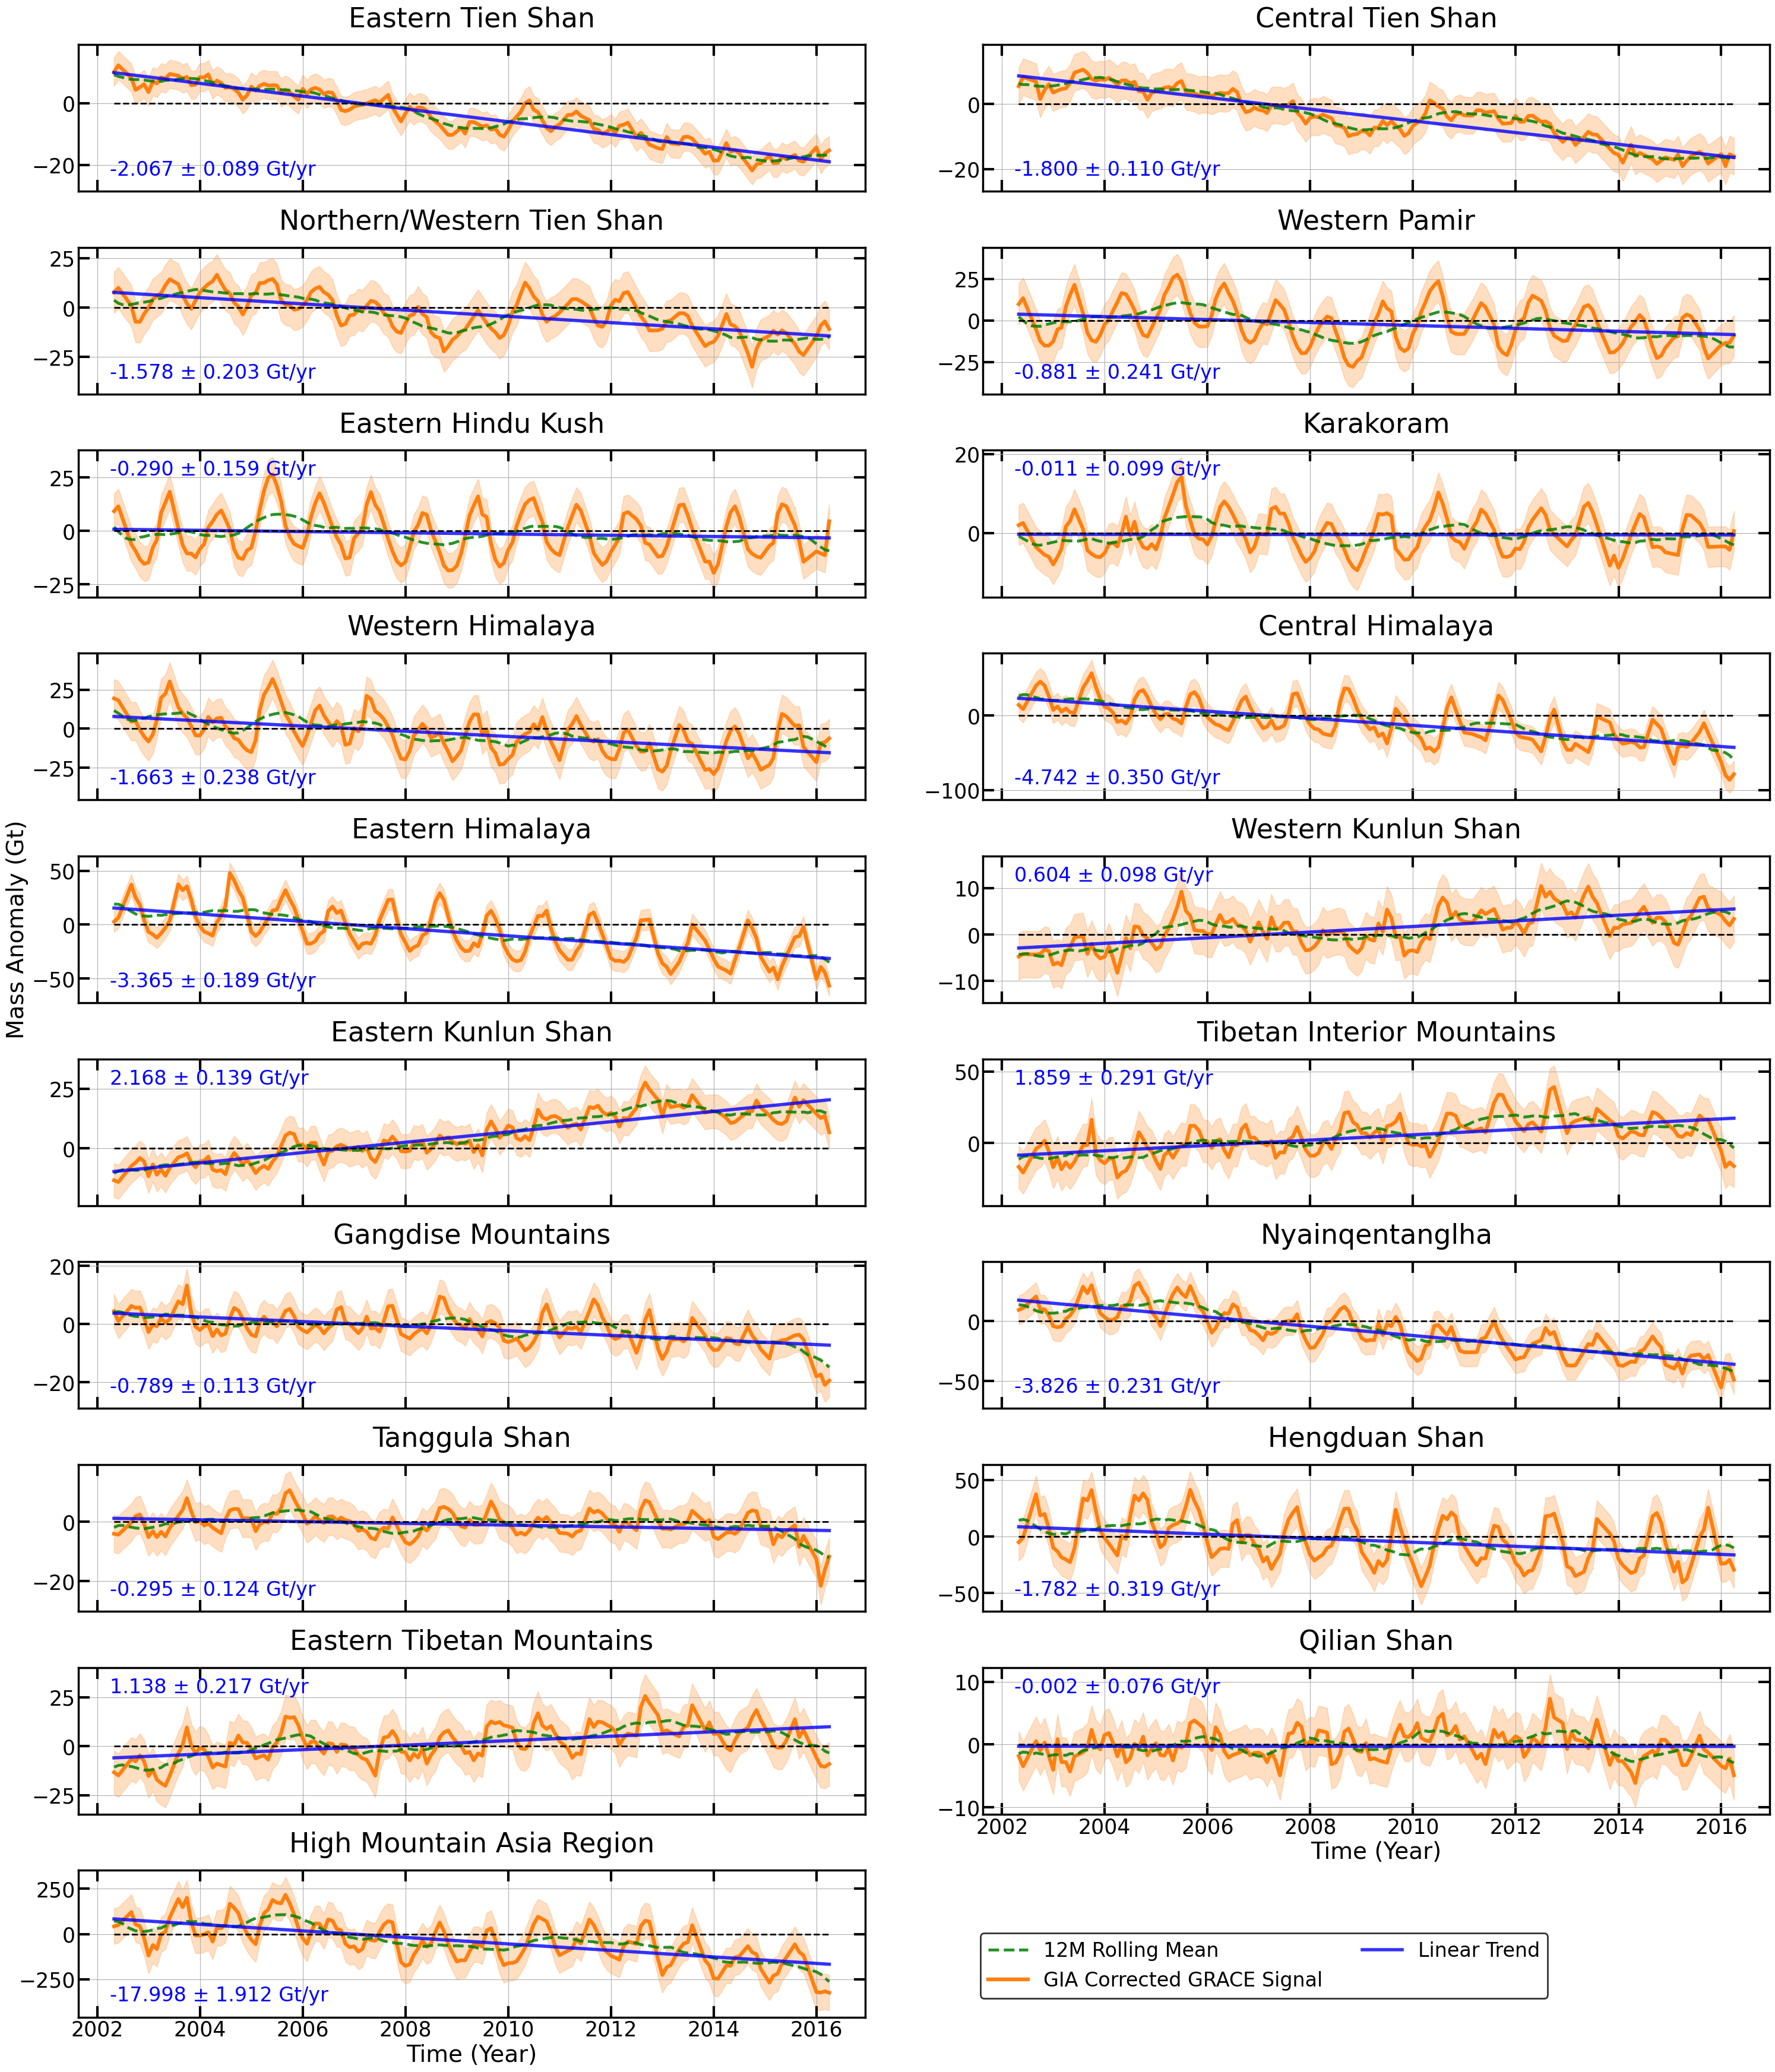

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from scipy.optimize import curve_fit

# Load region trends and uncertainty table (make sure region/titles match!)
trends_df = pd.read_csv(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/GRACE_GIA_corrected_signal_trends_Gt_per_year_withUncertainty1.csv')

# Set up lookup for region annotation
trend_lookup = trends_df.set_index('Primary_ID').to_dict(orient='index')

# Define datasets and colors
datasets = {
    "GIA Corrected GRACE Signal": "D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/Updated_HMA_RegionalAveraged_TWS_GIA_corrected_GRACEMascon_Signal_inGT_from_VCEMascon_approach1.csv",
}


dataset_colors = {
    "GIA Corrected GRACE Signal": "#ff7f0e",  # Orange
}

# Load region metadata and sort by region_id
region_metadata = pd.DataFrame({
    'region': [
        'Eastern Hindu Kush', 'Western Himalaya', 'Eastern Himalaya', 'Central Himalaya', 'Karakoram',
        'Western Pamir', 'Northern/Western Tien Shan', 'Western Kunlun Shan', 'Nyainqentanglha',
        'Gangdise Mountains', 'Hengduan Shan', 'Tibetan Interior Mountains', 'Tanggula Shan',
        'Eastern Tibetan Mountains', 'Qilian Shan', 'Eastern Kunlun Shan', 'Eastern Tien Shan',
        'Central Tien Shan', 'High Mountain Asia Region'
    ],
    'region_id': [8, 10, 12, 11, 9, 6, 4, 13, 18, 17, 20, 16, 19, 21, 22, 14, 2, 3, 23]
})
region_metadata_sorted = region_metadata.sort_values(by='region_id')
sorted_regions = region_metadata_sorted['region'].values

# Load glacier signal data with datetime index
dfs = {}
for name, file in datasets.items():
    df = pd.read_csv(file)
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    dfs[name] = df[sorted_regions]

# Constants for time conversion to fractional years
YEAR_NS = 365.25 * 24 * 60 * 60 * 1e9
t_ns = dfs["GIA Corrected GRACE Signal"].index.view('int64')

# Decomposition model: linear trend + annual & semiannual cycles
def decomp_func(t, a, b, c, d, e, f):
    t = t / YEAR_NS
    linear = a + b * t
    annual = c * np.sin(2 * np.pi * t) + d * np.cos(2 * np.pi * t)
    semi_annual = e * np.sin(4 * np.pi * t) + f * np.cos(4 * np.pi * t)
    return linear + annual + semi_annual

# Setup plot axes: 10 rows x 2 cols for 19 regions
fig, axes = plt.subplots(10, 2, figsize=(30, 36), sharex=True, sharey=False)
axes = axes.flatten()

time_index = dfs["GIA Corrected GRACE Signal"].index
start_year = time_index.min().year
end_year = time_index.max().year
x_ticks = pd.date_range(start=f'{start_year}', end=f'{end_year}', freq='2YS')

handle_labels = {}

for i, (_, row) in enumerate(region_metadata_sorted.iterrows()):
    region = row['region']
    region_id = row['region_id']
    ax = axes[i]
    df = dfs["GIA Corrected GRACE Signal"]
    y = df[region].values
    mask = np.isfinite(y)

    # Plot original monthly glacier signal
    raw_line, = ax.plot(
        df.index,
        y,
        color=dataset_colors["GIA Corrected GRACE Signal"],
        linestyle='-',
        # marker='o',
        linewidth=4.5,
        label="GIA Corrected GRACE Signal"
    )

    # --- Plot 12-month moving average (green line)
    roll_mean = df[region].rolling(window=12, center=True, min_periods=1).mean()
    roll_line, = ax.plot(
        roll_mean.index, roll_mean.values,
        color='green',
        linewidth=3.5,
        alpha=0.85,
        linestyle='--',
        label="12M Rolling Mean"
    )
    if i == 0:
        handle_labels["12M Rolling Mean"] = roll_line

    if mask.sum() > 6:
        try:
            # Fit decomposition model to monthly data
            params, _ = curve_fit(decomp_func, t_ns[mask], y[mask], p0=[np.nanmean(y), 0, 0, 0, 0, 0])
            a, b, c, d, e, f = params

            # Compute fitted model values over full time series
            fitted_curve = decomp_func(t_ns, *params)

            # Residuals = original - fitted
            residuals = y - fitted_curve
            resid_std = np.nanstd(residuals)

            # Linear trend line a + b*t (t in fractional years)
            t_fractional = t_ns / YEAR_NS
            linear_trend = a + b * t_fractional

            # Plot linear trend line (blue dashed)
            trend_plot, = ax.plot(
                df.index,
                linear_trend,
                color='blue',
                linestyle='-',
                linewidth=4,
                alpha=0.8,
                label="Linear Trend"
            )

            # Plot uncertainty envelope around fitted curve: ± 2 sigma of residuals
            upper_bound = y + 2 * resid_std
            lower_bound = y - 2 * resid_std

            ax.fill_between(
                df.index,
                lower_bound,
                upper_bound,
                color=dataset_colors["GIA Corrected GRACE Signal"],
                alpha=0.25,
                label="Uncertainty Envelope" if i == 0 else None
            )

            # Collect handles for legend only once
            if i == 0:
                handle_labels["GIA Corrected GRACE Signal"] = raw_line
                handle_labels["Linear Trend"] = trend_plot

        except RuntimeError:
            # If fit fails, skip plotting trend and envelope
            pass
    # ---- Annotation: Linear trend/uncertainty for region ----
    info = trend_lookup.get(region, None)
    if info is not None:
        annotation = f"{info['trend ± uncertainty (Gt/yr)']} Gt/yr"

        # Lower left (axes fraction coords)
        x_pos, y_pos = 0.04, 0.08
        if i in [4, 5,  9, 10, 11, 16, 17]:
            x_pos, y_pos = 0.04, 0.8
        ax.text(
            x_pos, y_pos, annotation,
            transform=ax.transAxes,
            fontsize=24,
            verticalalignment='bottom',
            color='blue', 
            horizontalalignment='left'
            # bbox=dict(facecolor='white', alpha=0.6, edgecolor='black', boxstyle='round,pad=0.3')
        )


    ax.set_title(region, fontsize=33, pad=22)
    ax.grid(True)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([tick.year for tick in x_ticks], rotation=0)
    ax.tick_params(axis='x', labelsize=25, direction='in', top=True, bottom=True, length=14, width=3)
    ax.tick_params(axis='y', labelsize=25, direction='in', left=True, right=True, length=14, width=3)
    ax.hlines(0, time_index.min(), time_index.max(), colors='k', linestyles='--', linewidth=2)

# Set thick black border for each subplot
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_edgecolor('black')

# Set axis labels
axes[8].set_ylabel('Mass Anomaly (Gt)', fontsize=28)
axes[17].set_xlabel('Time (Year)', fontsize=28)
axes[18].set_xlabel('Time (Year)', fontsize=28)
axes[17].tick_params(labelbottom=True)
axes[17].xaxis.get_label().set_visible(True)

# Legend on one axis (e.g., axes[18])
legend = axes[18].legend(
    handle_labels.values(),
    handle_labels.keys(),
    loc='center left',
    bbox_to_anchor=(1.134, 0.35),
    ncol=2,
    fontsize=24,
    frameon=True
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2)
axes[18].tick_params(labelbottom=True)

# Remove unused subplots if extra
for j in range(len(region_metadata_sorted), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.95, wspace=0.15)

# # Uncomment to save figure:
plt.savefig(r'D:/MSRSGI/Lab Rotation/Physical Geodesy/Python_Workspace/Organaized/Mascon/Combined/Result/Output_Data/Mascon_approach/Updated_HMA_RegionalAveraged_TWS_GIA_corrected_GRACEMascon_VCEMascon_approach_LinearTrend_MovingAverage_withEnvelope1.png', dpi=300, bbox_inches='tight')

plt.show()

------
-------
-------